# 05 - Merge de Telemetría y Encuestas

**Pregunta de negocio:** ¿Podemos unificar comportamiento vehicular con perfiles de comprador?

## Objetivos
- Cargar CSVs generados por el simulador
- Agregar telemetría a nivel de vehículo
- Merge con encuestas por vehicle_id
- Manejar datos faltantes
- Crear dataset unificado para análisis

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

## 1. Cargar datos desde CSVs

Flota: 50 | Encuestas: 500 | Telemetría: 6,076,720


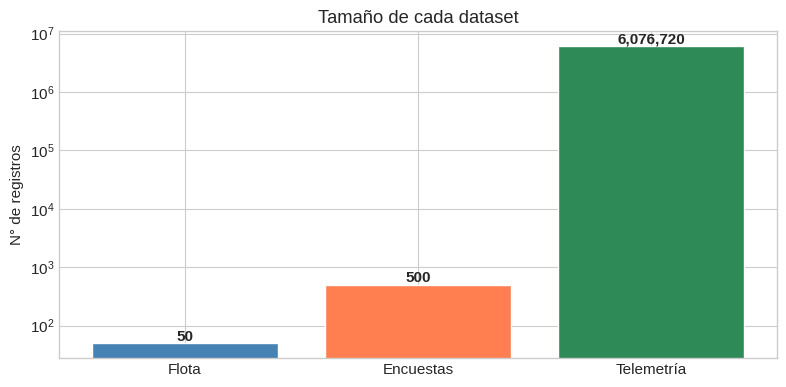

In [2]:
# Cargar flota y encuestas
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
surveys = pd.read_csv(os.path.join(data_dir, "surveys/buyer_surveys.csv"), parse_dates=["purchase_date"])

# Cargar telemetría (todos los archivos diarios)
telemetry_files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f, parse_dates=["timestamp"]) for f in telemetry_files], ignore_index=True)

print(f"Flota: {len(fleet)} | Encuestas: {len(surveys)} | Telemetría: {len(telemetry):,}")

# Visualizar tamaños
fig, ax = plt.subplots(figsize=(8, 4))
sizes = {'Flota': len(fleet), 'Encuestas': len(surveys), 'Telemetría': len(telemetry)}
bars = ax.bar(sizes.keys(), sizes.values(), color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
ax.set_ylabel('N° de registros')
ax.set_title('Tamaño de cada dataset')
ax.set_yscale('log')
for bar, v in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Agregar telemetría por vehículo

In [3]:
# Métricas agregadas por vehículo
vehicle_stats = telemetry.groupby("vehicle_id").agg(
    n_registros=("speed_kmh", "count"),
    n_viajes=("trip_id", "nunique"),
    speed_mean=("speed_kmh", "mean"),
    speed_max=("speed_kmh", "max"),
    speed_std=("speed_kmh", "std"),
    consumption_mean=("fuel_consumption_rate", "mean"),
    consumption_total=("fuel_consumption_rate", "sum"),
    battery_soc_mean=("battery_soc_pct", "mean"),
    battery_temp_max=("battery_temp_c", "max"),
    motor_rpm_mean=("motor_rpm", "mean"),
    motor_power_mean=("motor_power_kw", "mean"),
).reset_index()

# Frenadas bruscas
harsh = telemetry[telemetry["acceleration_ms2"] < -3].groupby("vehicle_id").size()
harsh.name = "harsh_braking_count"
vehicle_stats = vehicle_stats.merge(harsh.reset_index().rename(columns={0: "harsh_braking_count"}),
                                     on="vehicle_id", how="left")
vehicle_stats["harsh_braking_count"] = vehicle_stats["harsh_braking_count"].fillna(0).astype(int)

# Km estimados
vehicle_stats["estimated_km"] = (vehicle_stats["speed_mean"] * vehicle_stats["n_registros"] / 3600).round(1)

print(f"Estadísticas por vehículo: {vehicle_stats.shape}")
vehicle_stats.head()

Estadísticas por vehículo: (50, 14)


,vehicle_id,n_registros,n_viajes,speed_mean,speed_max,speed_std,consumption_mean,consumption_total,battery_soc_mean,battery_temp_max,motor_rpm_mean,motor_power_mean,harsh_braking_count,estimated_km
0,01cb4faa-246c-4ac4-967e-686646c718d0,97647,54,60.440368,123.89,36.220028,10.993354,1.073468e+06,NaN,55.0,1241.715752,58.945526,0,1639.4
1,05d940bb-0a44-4770-a2e0-465a8504b31e,92597,52,53.890560,123.21,34.455347,5.405120,5.004979e+05,98.813444,55.0,1194.027657,52.624132,0,1386.1
2,0ec4f37e-68a2-4f11-b8d3-afa45ce8883e,171318,87,54.152179,130.00,36.877091,8.108978,1.389214e+06,97.621252,55.0,1133.491968,51.200310,0,2577.0
3,0f83af6a-2312-4c76-9431-140c10b597c7,167626,84,62.040321,130.00,37.000107,15.180791,2.544695e+06,NaN,55.0,1428.615990,96.705558,0,2888.8
4,1b176ac7-e470-49a6-b1a5-b4c153f1f324,134850,72,55.979026,130.00,36.352443,11.099477,1.496764e+06,NaN,53.5,994.165873,29.661169,0,2096.9


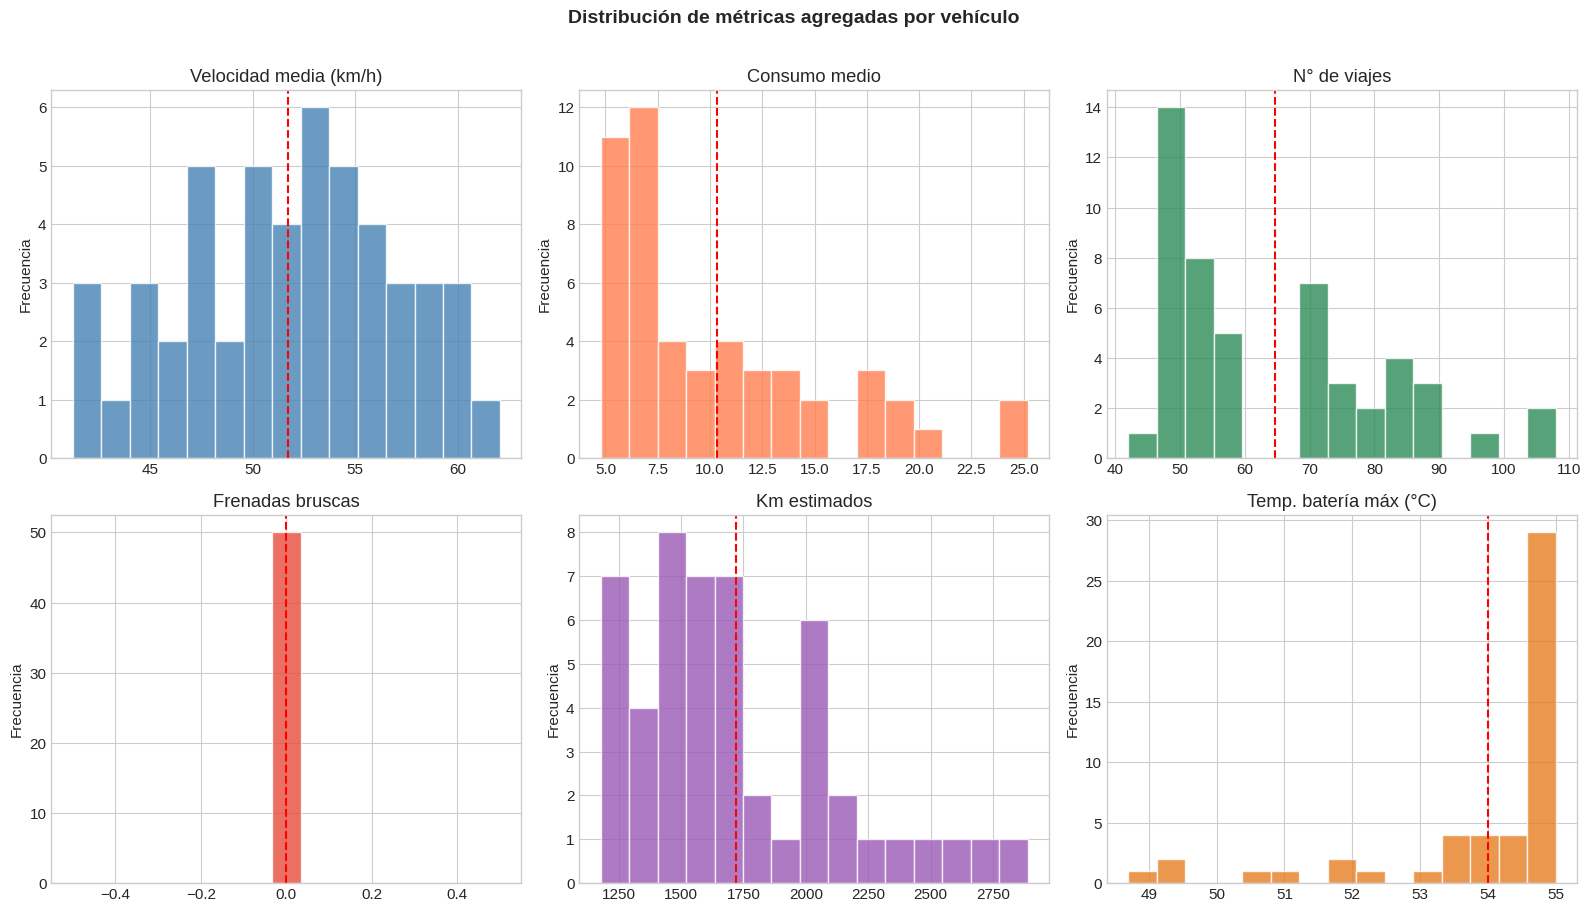

In [4]:
# Visualizar distribución de métricas agregadas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics = [
    ('speed_mean', 'Velocidad media (km/h)', 'steelblue'),
    ('consumption_mean', 'Consumo medio', 'coral'),
    ('n_viajes', 'N° de viajes', 'seagreen'),
    ('harsh_braking_count', 'Frenadas bruscas', '#e74c3c'),
    ('estimated_km', 'Km estimados', '#9b59b6'),
    ('battery_temp_max', 'Temp. batería máx (°C)', '#e67e22'),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    ax.hist(vehicle_stats[col].dropna(), bins=15, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(vehicle_stats[col].mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de métricas agregadas por vehículo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Merge: Telemetría + Flota + Encuestas

In [5]:
# Merge telemetría + flota
merged = vehicle_stats.merge(fleet, on="vehicle_id", how="left")

# Merge con encuestas (primera por vehicle_id)
surveys_unique = surveys.drop_duplicates(subset="vehicle_id", keep="first")
survey_cols = ["vehicle_id", "age", "gender", "income_bracket", "purchase_reason",
               "expected_usage", "driving_style", "satisfaction_score", "would_recommend", "km_driven"]
merged = merged.merge(surveys_unique[survey_cols], on="vehicle_id", how="left")
merged["has_survey"] = ~merged["age"].isnull()

print(f"Dataset unificado: {merged.shape}")
print(f"Con encuesta: {merged['has_survey'].sum()} | Sin encuesta: {(~merged['has_survey']).sum()}")

Dataset unificado: (50, 35)
Con encuesta: 50 | Sin encuesta: 0


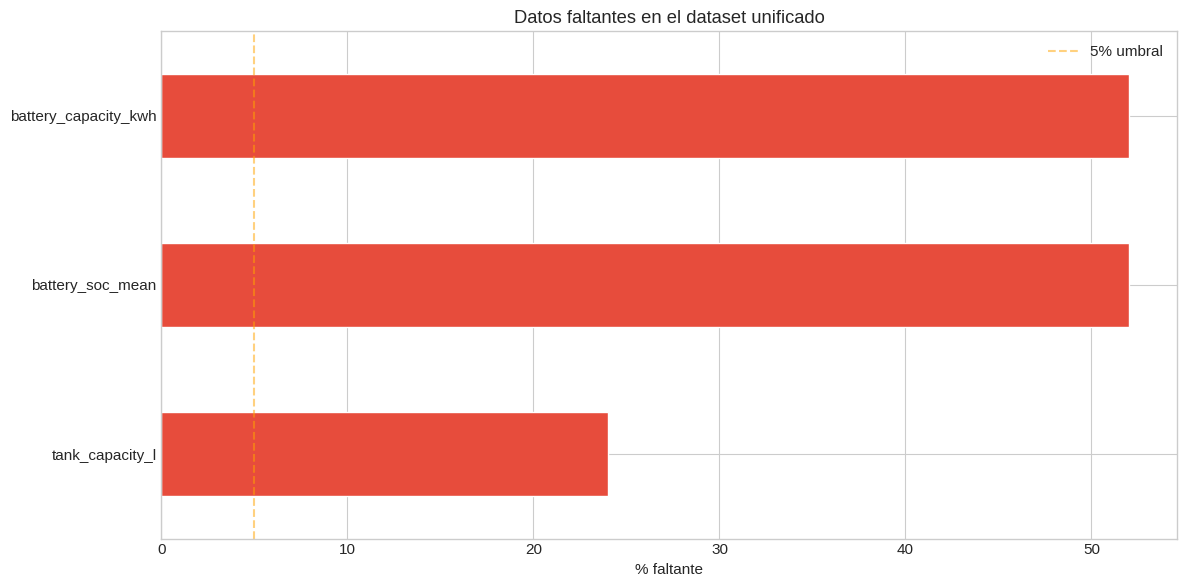

In [6]:
# Visualizar datos faltantes
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct = (merged.isnull().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    colors = ['#e74c3c' if v > 20 else '#e67e22' if v > 5 else '#2ecc71' for v in missing_pct]
    missing_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_xlabel('% faltante')
    ax.set_title('Datos faltantes en el dataset unificado')
    ax.axvline(5, color='orange', linestyle='--', alpha=0.5, label='5% umbral')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Sin datos faltantes', ha='center', va='center', fontsize=16, transform=ax.transAxes)
    ax.set_title('Datos faltantes en el dataset unificado')

plt.tight_layout()
plt.show()

## 4. Exploración del dataset unificado

/tmp/ipykernel_11040/2494276189.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=style_order, patch_artist=True)
/tmp/ipykernel_11040/2494276189.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot(bp_data2, labels=style_order, patch_artist=True)


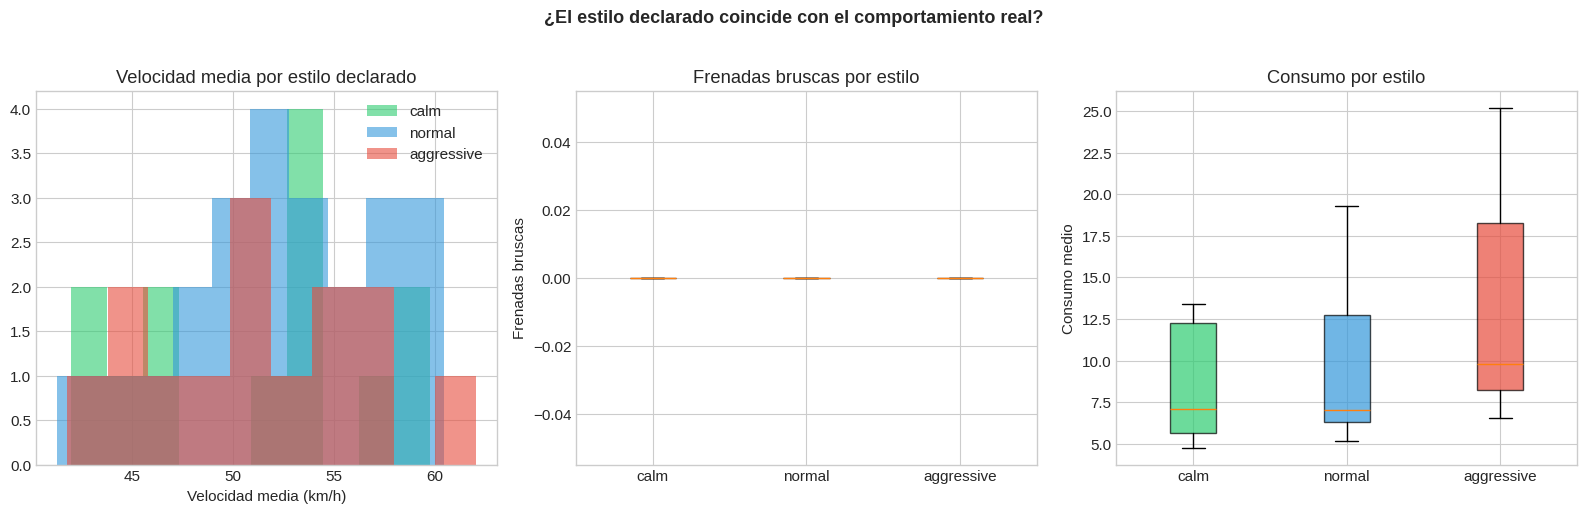

In [7]:
# Comportamiento real por estilo de conducción declarado
if merged['has_survey'].any():
    survey_data = merged[merged['has_survey']]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    style_colors = {'calm': '#2ecc71', 'normal': '#3498db', 'aggressive': '#e74c3c'}
    style_order = ['calm', 'normal', 'aggressive']

    # Velocidad media por estilo
    for style in style_order:
        subset = survey_data[survey_data['driving_style'] == style]
        axes[0].hist(subset['speed_mean'], bins=10, alpha=0.6, color=style_colors[style], label=style)
    axes[0].set_xlabel('Velocidad media (km/h)')
    axes[0].set_title('Velocidad media por estilo declarado')
    axes[0].legend()

    # Frenadas bruscas por estilo
    bp_data = [survey_data[survey_data['driving_style'] == s]['harsh_braking_count'] for s in style_order]
    bp = axes[1].boxplot(bp_data, labels=style_order, patch_artist=True)
    for patch, style in zip(bp['boxes'], style_order):
        patch.set_facecolor(style_colors[style])
        patch.set_alpha(0.7)
    axes[1].set_ylabel('Frenadas bruscas')
    axes[1].set_title('Frenadas bruscas por estilo')

    # Consumo por estilo
    bp_data2 = [survey_data[survey_data['driving_style'] == s]['consumption_mean'] for s in style_order]
    bp2 = axes[2].boxplot(bp_data2, labels=style_order, patch_artist=True)
    for patch, style in zip(bp2['boxes'], style_order):
        patch.set_facecolor(style_colors[style])
        patch.set_alpha(0.7)
    axes[2].set_ylabel('Consumo medio')
    axes[2].set_title('Consumo por estilo')

    plt.suptitle('¿El estilo declarado coincide con el comportamiento real?', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

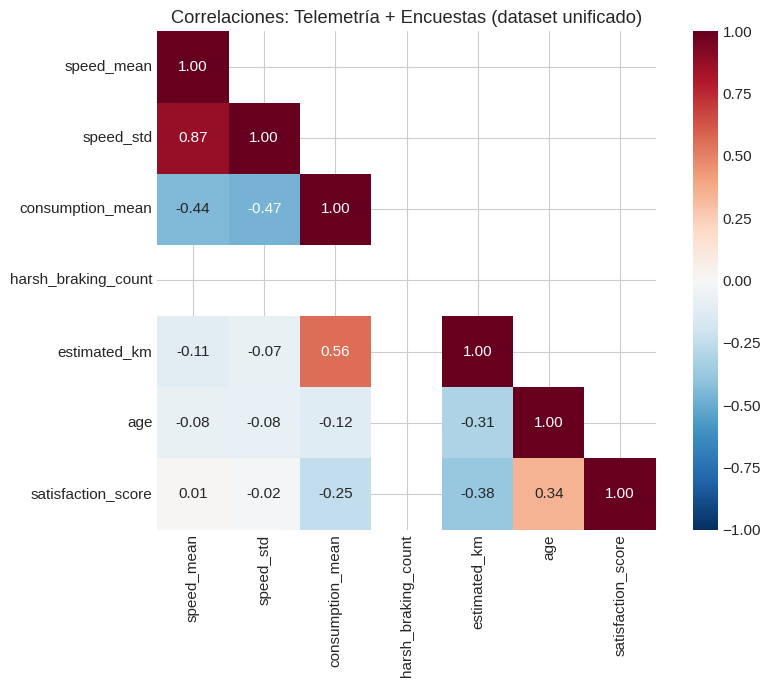

In [8]:
# Matriz de correlación del dataset unificado
if merged['has_survey'].any():
    numeric_merged = survey_data[['speed_mean', 'speed_std', 'consumption_mean',
                                   'harsh_braking_count', 'estimated_km',
                                   'age', 'satisfaction_score']].dropna()

    fig, ax = plt.subplots(figsize=(9, 7))
    corr = numeric_merged.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title('Correlaciones: Telemetría + Encuestas (dataset unificado)')
    plt.tight_layout()
    plt.show()

In [9]:
# Guardar dataset unificado
processed_dir = os.path.join(project_root, "data/processed")
os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(processed_dir, "vehicle_survey_merged.csv")
merged.to_csv(output_path, index=False)
print(f"Dataset guardado: {output_path}")
print(f"Tamaño: {os.path.getsize(output_path) / 1024:.1f} KB")

Dataset guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/processed/vehicle_survey_merged.csv
Tamaño: 15.6 KB


## 5. Tipos de join: visualización

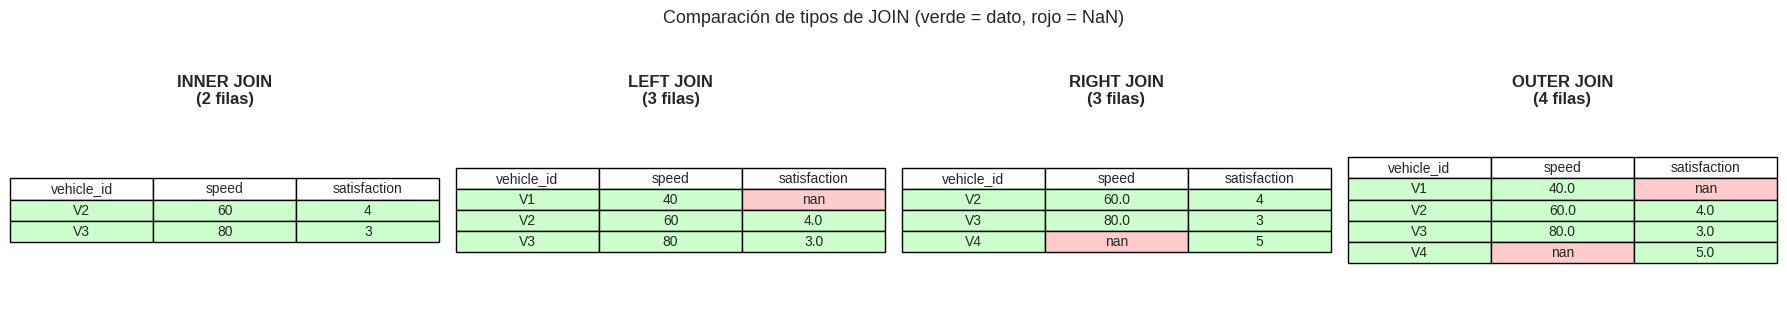

→ Para nuestro caso: LEFT join mantiene todos los vehículos aunque no tengan encuesta


In [10]:
# Demo visual de los 4 tipos de join
A = pd.DataFrame({"vehicle_id": ["V1", "V2", "V3"], "speed": [40, 60, 80]})
B = pd.DataFrame({"vehicle_id": ["V2", "V3", "V4"], "satisfaction": [4, 3, 5]})

fig, axes = plt.subplots(1, 4, figsize=(18, 3))

for ax, how in zip(axes, ["inner", "left", "right", "outer"]):
    result = A.merge(B, on="vehicle_id", how=how)
    # Colorear NaN
    cell_colors = []
    for _, row in result.iterrows():
        row_colors = []
        for val in row:
            if pd.isna(val):
                row_colors.append('#ffcccc')
            else:
                row_colors.append('#ccffcc')
        cell_colors.append(row_colors)

    ax.axis('off')
    table = ax.table(cellText=result.values, colLabels=result.columns,
                     cellColours=cell_colors, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax.set_title(f'{how.upper()} JOIN\n({len(result)} filas)', fontweight='bold', fontsize=12)

plt.suptitle('Comparación de tipos de JOIN (verde = dato, rojo = NaN)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print("→ Para nuestro caso: LEFT join mantiene todos los vehículos aunque no tengan encuesta")

## Resumen

### Entregable de la Fase 1:
- Simulador funcional en `src/simulator/`
- CSVs en `data/raw/` (flota, telemetría diaria, encuestas)
- Dataset unificado en `data/processed/vehicle_survey_merged.csv`

### Respuesta a la pregunta de negocio:
> **¿Podemos unificar comportamiento vehicular con perfiles de comprador?**
>
> Sí. El merge por vehicle_id conecta datos objetivos de conducción (velocidad,
> consumo, frenadas) con datos del comprador (edad, ingreso, satisfacción).
> Esto permite validar con datos si las percepciones de los compradores
> coinciden con su comportamiento real.

### Siguiente fase:
→ **Fase 2**: Análisis Exploratorio y Visualización profesional